In [2]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [3]:
using Revise
includet("./base.jl")
includet("./plotting_extras.jl")

In [4]:
using JLD2
using DataFrames, DataFramesMeta

In [5]:
using GLMakie
using CairoMakie
CairoMakie.activate!()

# Get data from all files

In [6]:
for f in files
    close(f)
end
GC.gc()

LoadError: UndefVarError: `files` not defined

In [8]:
ps = [1.0, 0.5, 0.1, 0.01]
files = map(ps) do p
    jldopen("./wrtp/d1_p$p.jld2")
end;
Ks = files[1]["metadata"].Ks;

In [14]:
full_df = DataFrame(;
    K=Float64[],
    p=Float64[],
    retcode=Any[],
    fT=Any[],
    fs=Any[],
)
for (p, f) in zip(ps, files)
    fKs = f["Ks"]
    results = f["results"]
    for i in 1:length(fKs)
        r = results[i]
        for (rc, fT, fs) in zip(r.retcodes, r.fTs, r.fss)
            push!(full_df, (fKs[i], p, rc, fT, fs))
        end
    end
end
df = @subset(full_df, :fT .== 1e8, :retcode .== ReturnCode.Success);
nrow(df)

1936

In [15]:
jldsave("./wrtp/df.jld2"; df=full_df, metadata=files[1]["metadata"])

# Number of survivors

In [19]:
df.num_surv = num_survivors_in_space.(df.fs, 2);

In [20]:
pgroups = @groupby(df, :p);

## Box plots

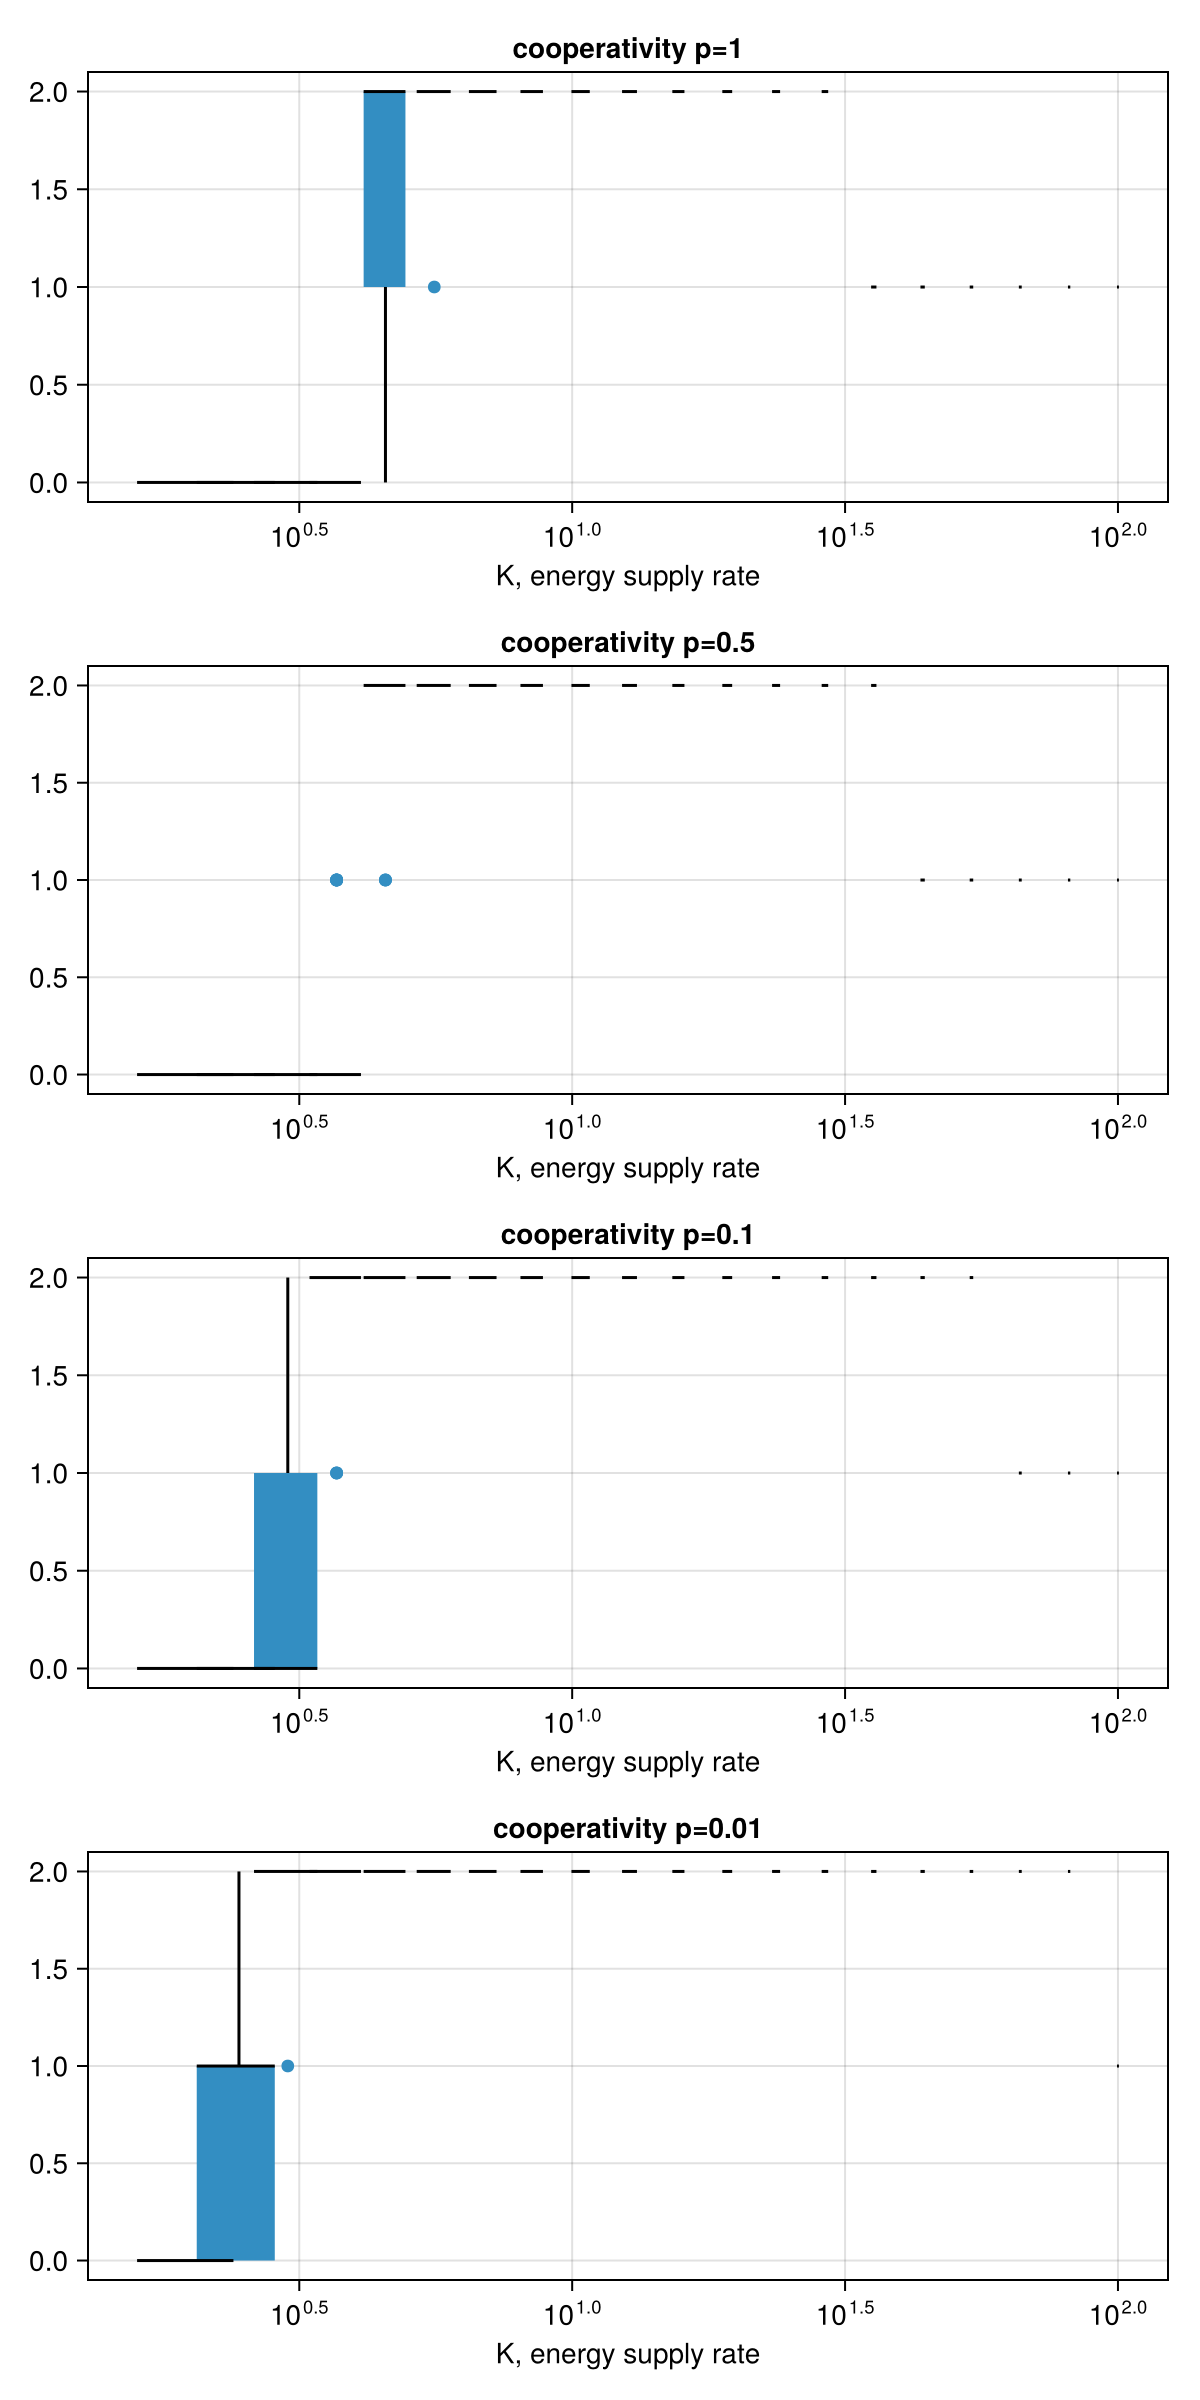

In [22]:
fig = Figure(;
    size=(600, 300 * length(pgroups))
)
for (i, sdf) in enumerate(pgroups)
    ax = Axis(fig[i,1];
        xscale=log10,
        title=(@sprintf "cooperativity p=%.3g" sdf.p[1]),
        xlabel="K, energy supply rate",
    )
    boxplot!(ax, sdf.K, sdf.num_surv)
end
Makie.save("wrtp/num_surv_bp.pdf", fig)
fig